In [1]:
%cd /Users/lucas/repositories/degeneracy_distillery/

/Users/lucas/repositories/degeneracy_distillery


/usr/local/Caskroom/miniconda/base/envs/pyoperon/lib/python3.12/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
pwd

'/Users/lucas/repositories/degeneracy_distillery'

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from pyoperon.sklearn import SymbolicRegressor
import multiprocessing
import csv
from sklearn.metrics import r2_score
import string
import sys,os
import sympy
import scipy

# ESR is optional - install separately if needed
try:
    import esr.generation.generator
except ImportError:
    print("Warning: ESR not installed. Install with: git clone https://github.com/DeaglanBartlett/ESR.git && pip install -e ESR")

import jax
import jax.numpy as jnp

from tqdm import tqdm as tq

# Add package to path - works with new directory name
sys.path.insert(0, '../degeneracy_distillery')



In [4]:
pwd

'/Users/lucas/repositories/degeneracy_distillery'

In [5]:
# from postprocessing_utils import load_and_process_data, process_ensemble_rotation

# Import preprocessing (rotations, data loading)
from preprocessing_utils import (
    load_and_process_data,
    process_ensemble_rotation,
    flatten_with_numerical_jacobian,
    batch_flatten_fisher,
    rotate_coords,
    load_and_process_data,
    weighted_std
)

# Import postprocessing (SR optimization)
from postprocessing_utils import (
    lossfn_jac_jax,
    get_component,
    get_pruned_expressions,
    get_pruned_expressions_final,
    check_flattening,
    make_check_flattening_fn,
)

# Create loss function
# _lossfn = lambda a: lossfn_jac_jax(
#     a, all_pars, all_fns, all_linear_pars, all_linear_inds,
#     X=X, Fs=Fs, n_params=n_params, delta=0.2, alpha=1.5
# )

# Option 1: Load and process in one call
data = load_and_process_data(
    datapath="",
    filename="/Users/lucas/repositories/degeneracy_distillery/data/fake_cmb_flatten_12_02_sum.npz",
      #/Users/lucas/repositories/degen_discovery/simple_problems/flattened_coords_little_sigma.npz",
    num_samps=4000,
    process_ensemble=True,  # <-- enables full processing
    n_d=1.0,
    verbose=True,
    y_reference_index=None,
    use_var=True
)

# Access results directly:
y = data['y']           # Weighted average outputs (masked)
y_std = data['y_std']   # Weighted std (masked)
dy = data['dy']         # Weighted average Jacobian (masked)
dy_sr = data['dy_sr']   # Weighted average rotated Jacobian
Fs = data['Fs']         # Weighted average Fisher
X = data['X']           # Parameters (masked)

norm_factor = data['norm_factor']

n_params = 6

# Option 2: Two-step process (more control)
# data = load_and_process_data(datapath="./", filename="fake_cmb_flatten_03_09_sum.npz", process_ensemble=False)
# result = process_ensemble_rotation(
#     datafile=data['datafile'],
#     randidx=data['randidx'],
#     Favg=data['Favg'],
#     best_model_idx=data['best_model_idx'],
#     n_d=1.0
# )

best model 18
Network 0: y.min() = -2.903804, weight = 19251.5
thetastar [0.6315514  0.44120693 0.54719007 0.44854033 0.4729259  0.46151984]
using var F
  Shapes: y=(4000, 6), X=(4000, 6)
Network 1: y.min() = -2.721252, weight = 267.7
thetastar [0.6315514  0.44120693 0.54719007 0.44854033 0.4729259  0.46151984]
using var F
  Shapes: y=(4000, 6), X=(4000, 6)
Network 2: y.min() = -2.525544, weight = 3588.5
thetastar [0.6315514  0.44120693 0.54719007 0.44854033 0.4729259  0.46151984]
using var F
  Shapes: y=(4000, 6), X=(4000, 6)
Network 3: y.min() = -2.905065, weight = 20476.8
thetastar [0.6315514  0.44120693 0.54719007 0.44854033 0.4729259  0.46151984]
using var F
  Shapes: y=(4000, 6), X=(4000, 6)
Network 4: y.min() = -2.987429, weight = 20944.0
thetastar [0.6315514  0.44120693 0.54719007 0.44854033 0.4729259  0.46151984]
using var F
  Shapes: y=(4000, 6), X=(4000, 6)
Network 5: y.min() = -2.599250, weight = 1094.4
thetastar [0.6315514  0.44120693 0.54719007 0.44854033 0.4729259  0.461

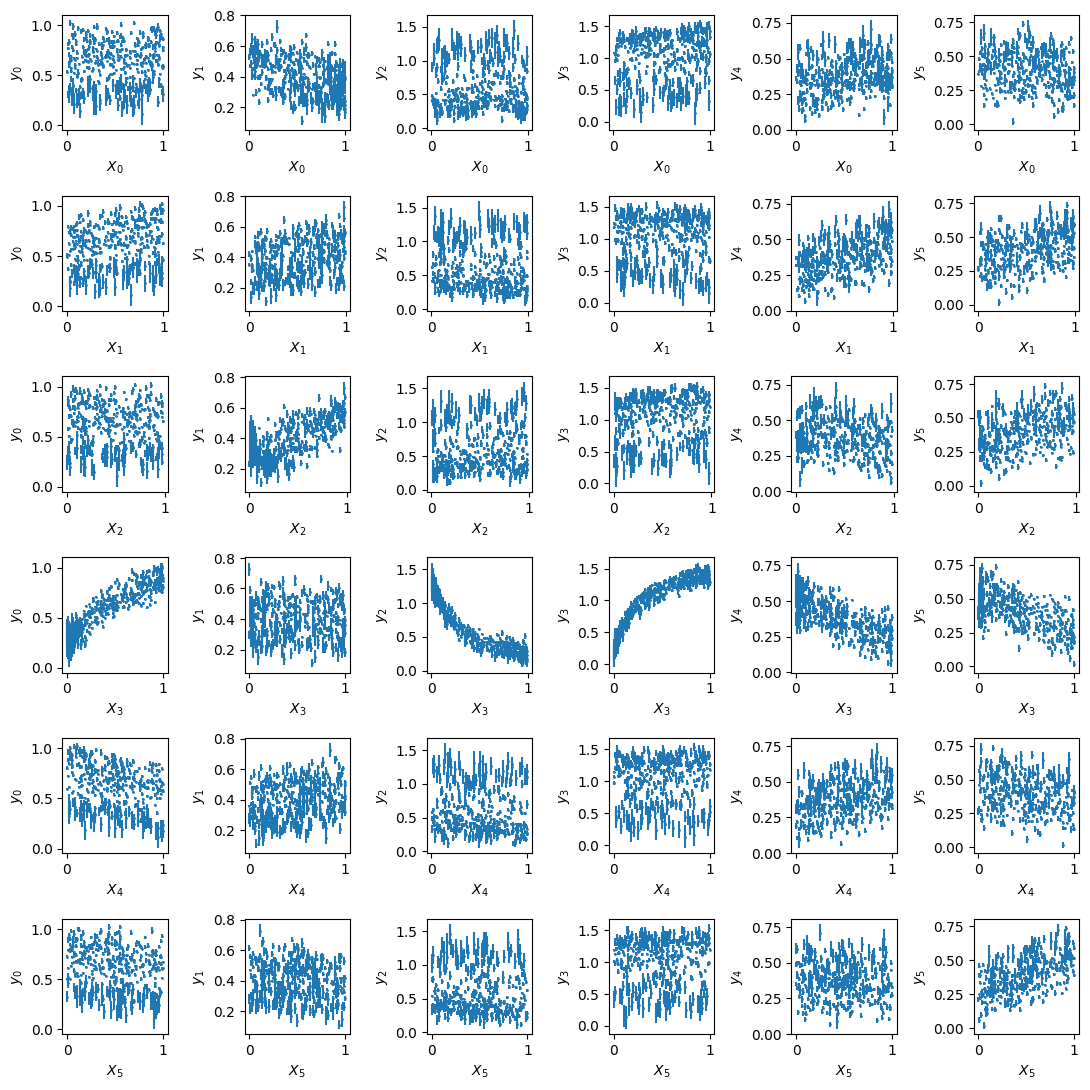

In [6]:
# create scatterplot to see how y responds to X

fig, axs = plt.subplots(n_params, n_params, figsize=(11,11))

skip=10

for i in range(X.shape[-1]):
    for j in range(y.shape[-1]):
        
        # row, column
        axs[i,j].errorbar(X[::skip,i], y[::skip, j], yerr=y_std[::skip, j], label='', fmt='o', markersize=1)

        axs[i,j].set_xlabel(r"$X_%d$"%(i))
        axs[i,j].set_ylabel(r"$y_%d$"%(j))

plt.tight_layout()
plt.show()

In [7]:
y[0]

array([0.9832647 , 0.48911634, 0.31819612, 1.317123  , 0.27960086,
       0.23816767], dtype=float32)

In [8]:
np.cov(y, rowvar=False).shape

Text(0, 0.5, '$y$')

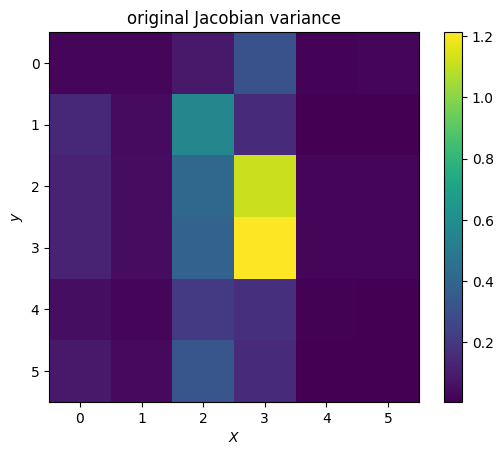

In [9]:
plt.imshow(dy.std(0))
plt.colorbar()
plt.title('original Jacobian variance')
plt.xlabel("$X$")
plt.ylabel("$y$")

Text(0, 0.5, '$y$')

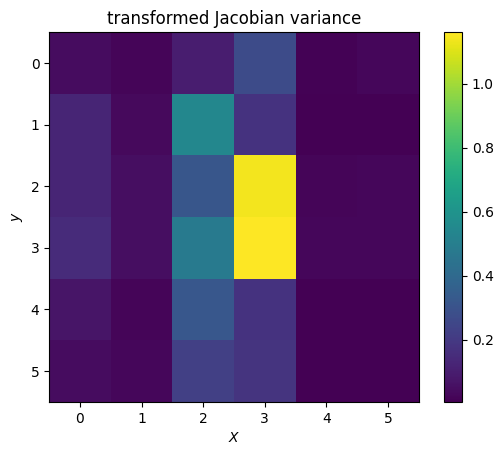

In [10]:
plt.imshow(dy_sr.std(0))
plt.colorbar()
plt.title('transformed Jacobian variance')
plt.xlabel("$X$")

plt.ylabel("$y$")

Text(0, 0.5, '$y$')

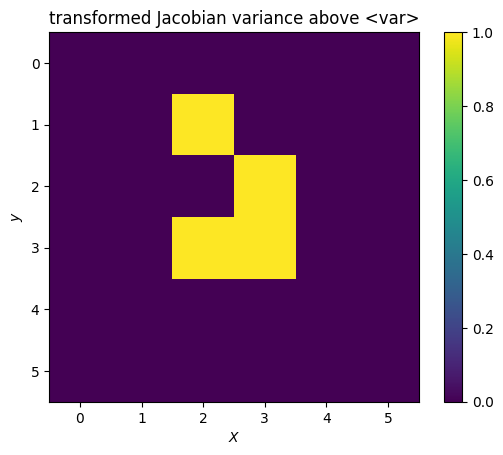

In [11]:
plt.imshow(dy_sr.var(0) > (dy_sr.var(0).mean()))
plt.colorbar()
plt.title('transformed Jacobian variance above <var>')
plt.xlabel("$X$")
plt.ylabel("$y$")

Text(0, 0.5, '$y$')

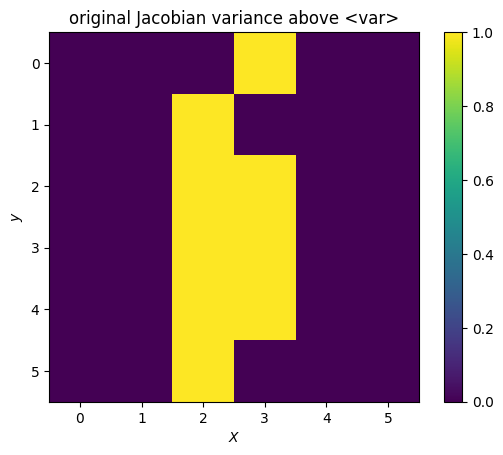

In [12]:
plt.imshow(dy.std(0) > (dy.std(0).mean()))
plt.colorbar()
plt.title('original Jacobian variance above <var>')
plt.xlabel("$X$")
plt.ylabel("$y$")

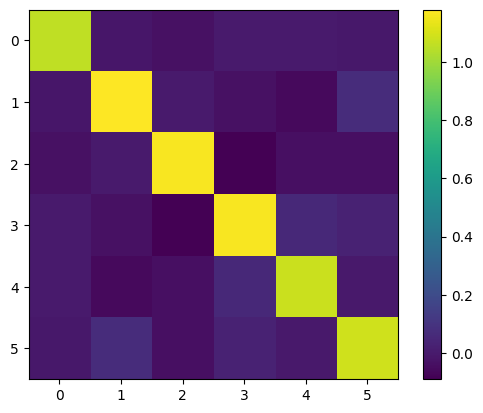

In [13]:
# foo = dy_sr / np.sqrt(0.5)
plt.imshow(jax.vmap(flatten_with_numerical_jacobian)(dy, Fs).mean(0))
plt.colorbar()

Text(0, 0.5, '$\\langle\\eta_{0,j}\\rangle$')

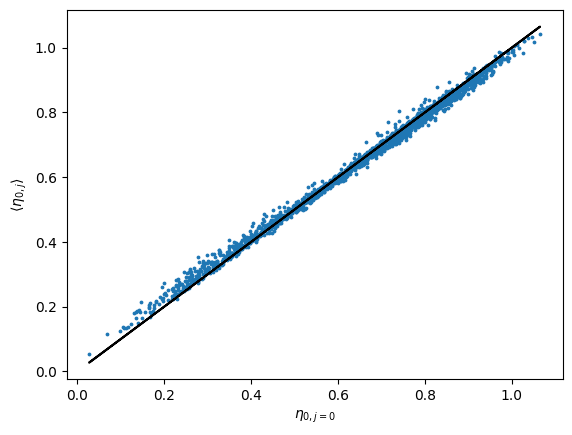

In [14]:
plt.scatter(data['ys'][0, ::2, 0], np.average(data['ys'][1:, ::2, 0], axis=0, \
                            weights=(data['ensemble_weights'][1:])), s=3) 

plt.plot(data['ys'][0, ::2, 0],data['ys'][0, ::2, 0], c='k')
plt.xlabel(r"$\eta_{0,j=0}$")
plt.ylabel(r"$\langle\eta_{0,j}\rangle$")

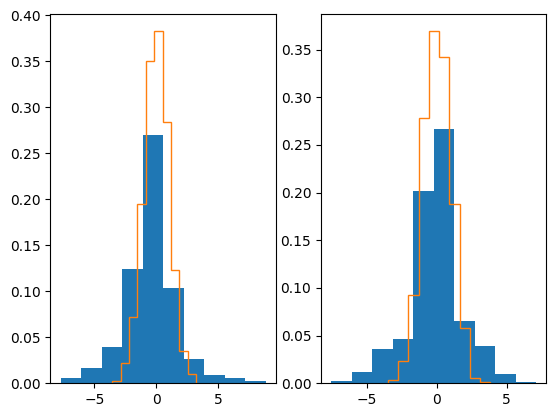

In [15]:
fig,axs = plt.subplots(1,2)
axs = axs.flatten()

for i,ax in enumerate(axs):
    ax.hist(((data['ys'] - y) / y_std)[:, :, i].flatten(), density=True)
    ax.hist(np.random.normal(size=(2000,)).flatten(), histtype='step', density=True)

In [16]:
(np.sqrt(np.linalg.det(Fs).mean()))

0.02056111

# try out symbolic fitting code

In [17]:
from sr_utils import fit_and_analyze_sr

# Split your data
# halfx = X.shape[0] // 2
# X_train, X_val = X[:halfx], X[halfx:]
# y_train, y_val = y[:halfx], y[halfx:]
# Fs_train, Fs_val = Fs[:halfx], Fs[halfx:]
# dy_sr_train, dy_sr_val = dy_sr[:halfx], dy_sr[halfx:]
# y_std_train, y_std_val = y_std[:halfx], y_std[halfx:]
# ... same for other arrays

# Run complete pipeline
parent_dir = './example_2/'

# Simple! Just pass your full arrays
mdl_coords, frob_coords, analysis, split_data = fit_and_analyze_sr(
    X, y, y_std, dy_sr, Fs,
    parent_dir=parent_dir,
    n_params=6,
    allowed_symbols='add,mul,pow,constant,variable,exp,sqrt,log',  # no log
    max_length=20,              # shorter equations
    time_limit=20,             # 5 minutes per component
    objectives=['rmse', 'length'],  # RMSE instead of R2
    equation_set='both'
)

print("Best MDL coordinates:", mdl_coords)
print("Best Frob coordinates:", frob_coords)


Fitting component 1 of 6 (index 0)
X train shape: (2000, 6), y train shape: (2000,)
Fitting...
Done!
Best model: (0.34 + (0.68 * (0.86 * X4)))
Stats: {'model_length': 1, 'model_complexity': 3, 'generations': 248, 'evaluation_count': 0, 'residual_evaluations': 1280484, 'jacobian_evaluations': 878197, 'random_state': 2345}
Outputting 15 individuals on Pareto front
Outputting 2000 individuals in population

Fitting component 2 of 6 (index 1)
X train shape: (2000, 6), y train shape: (2000,)
Fitting...
Done!
Best model: (0.25 + (0.34 * (0.92 * X3)))
Stats: {'model_length': 1, 'model_complexity': 3, 'generations': 170, 'evaluation_count': 0, 'residual_evaluations': 946892, 'jacobian_evaluations': 645245, 'random_state': 2345}
Outputting 20 individuals on Pareto front
Outputting 2000 individuals in population

Fitting component 3 of 6 (index 2)
X train shape: (2000, 6), y train shape: (2000,)
Fitting...
Done!
Best model: (0.09 + (1.09 * exp(((-2.16) * X4))))
Stats: {'model_length': 2, 'model

Component 1:  56%|█████▌    | 352/629 [01:19<01:02,  4.43it/s]


KeyboardInterrupt: 

2000


In [18]:
analysis.keys()

dict_keys(['latex', 'equations', 'frobloss', 'DL', 'logL', 'complexity', 'ibest_mdl', 'ibest_frob'])

In [24]:
analysis['logL'][4]

array([22371.70703125, 22523.42773438, 12044.37890625,  8081.15527344,
        6162.80957031,  4840.21191406,  1557.39160156,     0.        ])

In [19]:
analysis['latex'][1]

['X_{3} b_{1} b_{2} + b_{0}',
 'b_{0} + b_{1} e^{X_{3} b_{2}}',
 'b_{0} + b_{1} \\left(X_{1} b_{2} + X_{3} b_{3}\\right)',
 'b_{0} + b_{1} \\left(X_{3} b_{2}\\right)^{e^{X_{1} b_{3}}}',
 'b_{0} + b_{1} \\left(X_{1} b_{2} + X_{2} b_{3} + X_{3} b_{4}\\right)',
 'b_{0} + b_{1} \\left(X_{2} b_{2} + X_{3} b_{3}\\right)^{e^{X_{1} b_{4}}}',
 'b_{0} + b_{1} \\left(X_{1} b_{4} + X_{2} b_{2} + X_{3} b_{3} + X_{5} b_{5}\\right)',
 'b_{0} + b_{1} \\left(X_{6} b_{5} + \\left(X_{2} b_{2} + X_{3} b_{3}\\right)^{e^{X_{1} b_{4}}}\\right)',
 'b_{0} + b_{1} \\left(X_{1} b_{6} + X_{2} b_{2} + X_{3} b_{3} + X_{6} b_{4} + b_{5}\\right)']

In [20]:
# Access test data for further analysis
X_test = split_data['X_test']
y_test = split_data['y_test']
Fs_test = split_data['Fs_test']
y_std_test = split_data['y_std_test']
dy_sr_test = split_data['dy_sr_test']


In [21]:
Fs.shape, X.shape, y.shape, y_std.shape, dy_sr.shape

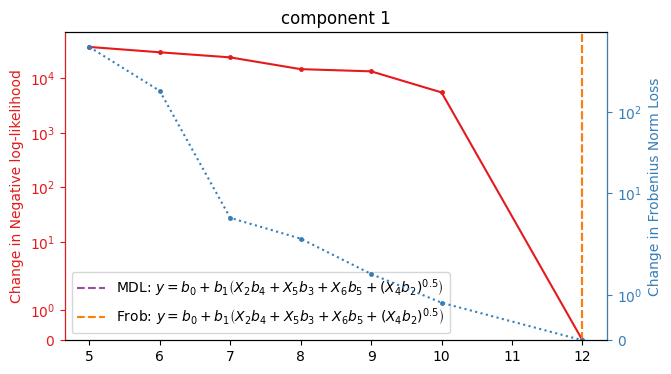

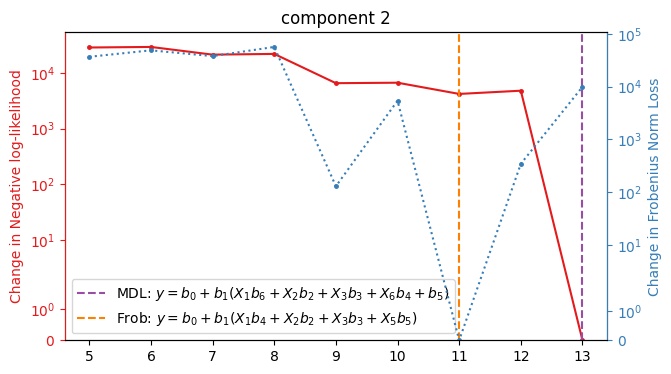

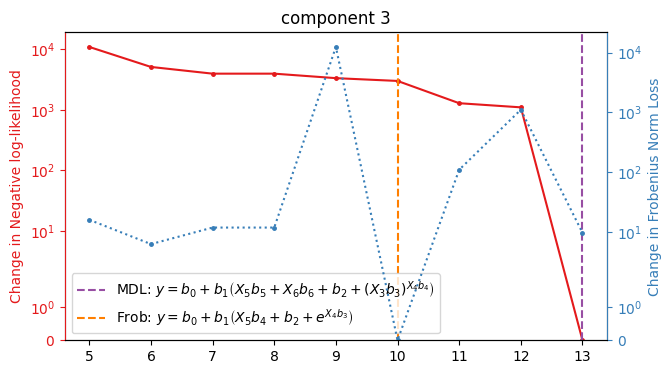

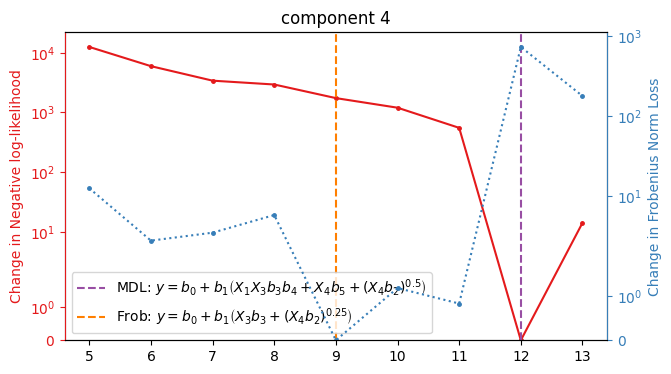

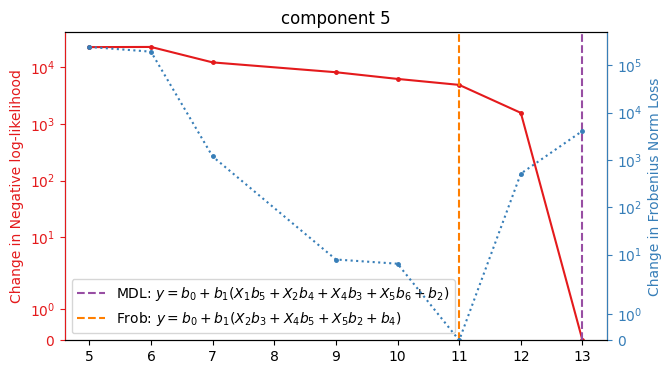

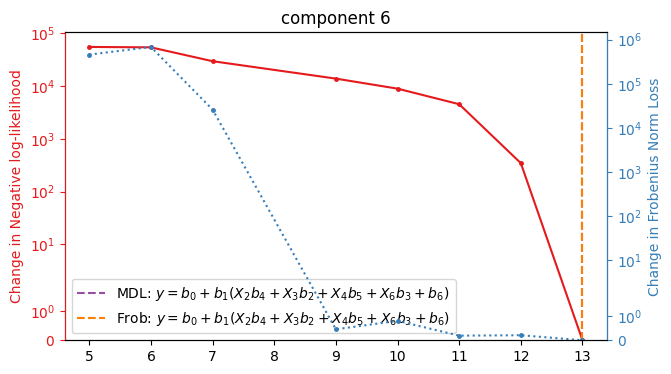

In [25]:
# components_to_fit = [0,1]

# Access the best equation indices for component 0
ibest_mdl = analysis['ibest_mdl'][0]    # index of best MDL equation
ibest_frob = analysis['ibest_frob'][0]  # index of best Frob equation

# Get the actual equations at those indices
best_mdl_eq = analysis['equations'][0][ibest_mdl]
best_frob_eq = analysis['equations'][0][ibest_frob]

# Access other metrics at those indices
mdl_complexity = analysis['complexity'][0][ibest_mdl]
frob_complexity = analysis['complexity'][0][ibest_frob]



n_components = 6

both_comp_latex = []
both_comp_eqs = []
both_comp_frobloss = []
both_comp_logL = []
both_comp_DL = []


max_complexity_thresh = 15

for i in range(n_components):

    idx = i


    # Access the best equation indices for component 0
    ibest_mdl = analysis['ibest_mdl'][i]    # index of best MDL equation
    ibest_frob = analysis['ibest_frob'][i]  # index of best Frob equation

    # Get the actual equations at those indices
    best_mdl_eq = analysis['equations'][i][ibest_mdl]
    best_frob_eq = analysis['equations'][i][ibest_frob]

    # Access other metrics at those indices
    mdl_complexity = analysis['complexity'][i][ibest_mdl]
    frob_complexity = analysis['complexity'][i][ibest_frob]
    


    fig, ax1 = plt.subplots(1, 1, figsize=(7,4), sharex=True)
    cm = plt.get_cmap('Set1')
    ax2 = ax1.twinx()
    
    #ax1.plot(complexity, pareto_DL, marker='.', color=cm(0), markersize=5, )
    # ax2.plot(complexity, pareto_logL, marker='.', color=cm(1), markersize=5, ls=':')
    ax1.plot(analysis['complexity'][i], analysis['logL'][i], marker='.', color=cm(0), markersize=5, )
    ax2.plot(analysis['complexity'][i], analysis['frobloss'][i], marker='.', color=cm(1), markersize=5, ls=':')


    #ax1.set_ylabel('Change in Description Length')
    # ax2.set_ylabel('Change in Negative log-likelihood')
    ax1.set_ylabel('Change in Negative log-likelihood')
    ax2.set_ylabel('Change in Frobenius Norm Loss')
    ax1.yaxis.label.set_color(cm(0))
    ax1.tick_params(axis='y', colors=cm(0))
    ax2.spines['left'].set_color(cm(0))

    ax2.yaxis.label.set_color(cm(1))
    ax2.tick_params(axis='y', colors=cm(1))
    ax2.spines['right'].set_color(cm(1))

    ax1.set_yscale('symlog')
    ax2.set_yscale('symlog')
    ax1.set_ylim(0, None)
    ax2.set_ylim(0, None)

    pareto_latex = analysis['latex'][i]
    #ax1.axvline(complexity[pysr_ibest], color=cm(2), ls=':', label=r'Score: $y = %s$'%all_latex[pysr_ibest])
    ax1.axvline(analysis['complexity'][i][ibest_mdl], color=cm(3), ls='--', label=r'MDL: $y = %s$'%pareto_latex[ibest_mdl])
    ax1.axvline(analysis['complexity'][i][ibest_frob], color=cm(4), ls='--', label=r'Frob: $y = %s$'%pareto_latex[ibest_frob])

    ax1.legend()
    plt.title("component %d"%(idx + 1))
    plt.show()
    #fig.savefig('function_ranking.png', bbox_inches='tight', facecolor='white')


In [27]:
mdl_coords

['(0.198915 + (0.740551 * (((sqrt((0.997869 * X4)) + ((-0.254262) * X5)) + (0.231963 * X2)) + ((-0.131264) * X6))))',
 '((-0.000005) + (0.999998 * ((((0.146357 * X2) + (0.297831 * X3)) + ((-0.113143) * X6)) + (0.335804 + ((-0.177085) * X1)))))',
 '((-0.043820) + (1.062336 * ((0.385171 + ((0.001209 * X3) ^ (0.474258 * X4))) + (((-0.113036) * X5) + ((-0.101597) * X6)))))',
 '((-0.070241) + (1.024071 * ((sqrt((5.114736 * X4)) + ((6.283185 * X3) * (0.040789 * X1))) + ((-0.888934) * X4))))',
 '(0.000000 + (1.000001 * (((0.303160 + ((-0.296884) * X4)) + (0.174063 * X2)) + ((0.113381 * X1) + (0.132586 * X5)))))',
 '((-0.000004) + (0.999999 * (((((0.133432 * X3) + (0.226473 * X6)) + (0.168353 * X2)) + ((-0.266463) * X4)) + 0.262993)))']

# post-process SR expressions

In [28]:
%load_ext autoreload
%autoreload 2

In [29]:
pwd

'/Users/lucas/repositories/degeneracy_distillery'

In [30]:
# Import postprocessing (SR optimization)
from postprocessing_utils import (
    lossfn_jac_jax,
    get_component,
    get_pruned_expressions,
    get_pruned_expressions_final,
    check_flattening,
    make_check_flattening_fn,
    get_Q_jax, construct_M
)




### demo


In [31]:
all_pars = []
all_linear_pars = []
all_fns = []
all_linear_inds = []
all_param_dicts = []
all_xs = []
all_bs = []

all_expr = []

all_linear_labels = []

for i in range(n_params):
    # lab, expr, prs, _x, _b, eq_fn, oldexpr, nodes = get_component(mdl_coordinates[i], i)

    lab, expr, prs, linear_prs, _x, _b, eq_fn, param_dict, linear_inds = get_component(mdl_coords[i], i, X=X, module="jax")
    all_pars.append(prs)
    all_linear_pars.append(linear_prs)
    all_fns.append(eq_fn)
    all_xs.append(_x)
    all_bs.append(_b)
    all_linear_inds.append(linear_inds)
    all_param_dicts.append(param_dict)
    all_expr.append(expr)

    all_linear_labels.append([_b[l] for l in linear_inds])



In [32]:
import numpy as np
from scipy.optimize import minimize

def sparse_rotation_loss(A_flat, M, lambda_ortho=1.0, alpha=1.0):
    """
    A_flat: Flattened rotation matrix A (size N*N)
    M:      Coefficient matrix (size N*T)
    lambda_ortho: Weight for orthogonality constraint
    alpha:  Scaling factor for log-cosh (controls steepness)
    """
    # 1. Reshape A back to square matrix
    dim = int(np.sqrt(len(A_flat)))
    A = A_flat.reshape((dim, dim))
    # A = get_Q_jax(A)
    
    # 2. Calculate Rotated Factors (y_pred components)
    # y_pred = A @ M (The projection we want to be sparse)
    transformed_M = A @ M
    
    # 3. Sparsity Loss (Log-Cosh approximation of L1)
    # Behaving like L2 near 0 and L1 away from 0. Differentiable.
    sparsity_loss = np.sum(np.log(np.cosh(alpha * transformed_M))) / alpha
    
    # 4. Orthogonality Constraint (Soft Penalty)
    # Forces A^T @ A to be close to Identity
    I = np.eye(dim)
    ortho_loss = np.linalg.norm(A.T @ A - I, ord='fro')**2
    
    # 5. Total Loss
    total_loss = sparsity_loss + (lambda_ortho * ortho_loss)
    
    return total_loss

# --- Example Usage ---

# 1. Setup Synthetic Data
np.random.seed(67)
N_dim = n_params   # Dimension of the basis (rows of M)
T_samples = 100 # Number of samples (cols of M)

# Create a random coefficient matrix M (dense initially)
# M = np.random.randn(N_dim, T_samples)
M = construct_M(all_linear_pars, n_params=n_params)

# 2. Initialize A
# Start with Identity or a random orthogonal matrix
# A_init = np.eye(N_dim).flatten()
A_init = get_Q_jax((np.random.randn(n_params*n_params)* (2./n_params**2)).reshape(n_params, n_params)).flatten()

# 3. Optimization Configuration
# lambda_ortho: How hard to enforce rotation constraint vs sparsity
# alpha: Higher values make log-cosh closer to true L1 (but harder to optimize)
loss_args = (M, 4.0, 1.5) 

print("Optimizing...")
result = minimize(
    fun=sparse_rotation_loss,
    x0=A_init,
    args=loss_args,
    method='L-BFGS-B',
    options={'disp': True, 'maxiter': 100000}
)

# 4. Extract Results
A_opt = result.x.reshape((N_dim, N_dim))
# A_opt = get_Q_jax(A_opt)
M_sparse = A_opt @ M

print("\nOptimization Success:", result.success)
print(f"Final Loss: {result.fun:.4f}")

# Check Orthogonality (Should be close to Identity)
ortho_check = A_opt.T @ A_opt
print("\nCheck A^T @ A (Diagonal should be ~1.0):")
print(np.round(np.diag(ortho_check), 4))

# Visual check of Sparsity (Kurtosis increases if sparsity increases)
from scipy.stats import kurtosis
kurt_original = np.mean(kurtosis(M, axis=1))
kurt_rotated = np.mean(kurtosis(M_sparse, axis=1))
print(f"\nAvg Kurtosis (Original M): {kurt_original:.2f}")
print(f"Avg Kurtosis (Rotated M):  {kurt_rotated:.2f} (Higher is sparser)")

Aopt = A_opt

Optimizing...

Optimization Success: True
Final Loss: 7.8151

Check A^T @ A (Diagonal should be ~1.0):
[0.9432 0.9048 0.8928 0.     0.896  0.8929]

Avg Kurtosis (Original M): 20.76
Avg Kurtosis (Rotated M):  5.24 (Higher is sparser)


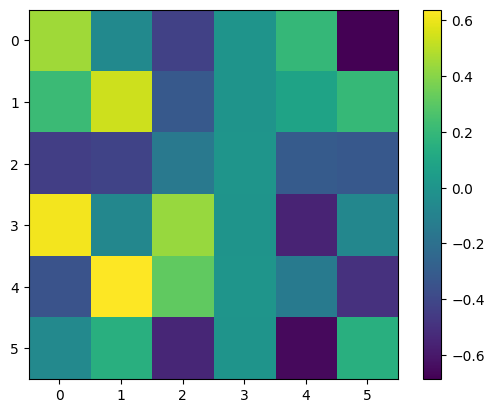

In [33]:
plt.imshow(Aopt)
plt.colorbar()

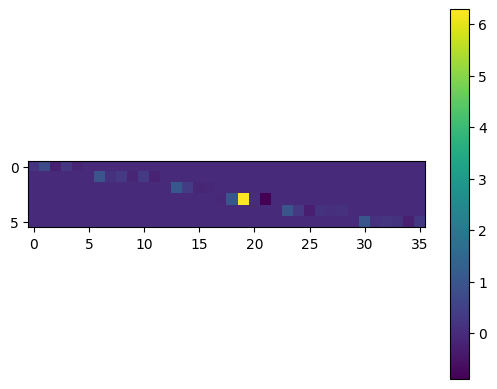

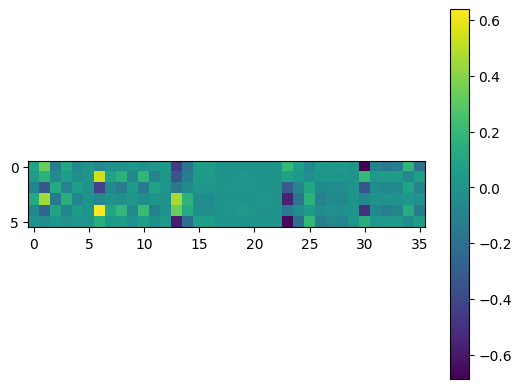

In [34]:
plt.imshow(M)
plt.colorbar()
plt.show()
plt.imshow(M_sparse)
plt.colorbar()
plt.show()

In [ ]:
from scipy.optimize import minimize
import jax.scipy.optimize


np.random.seed(0)

Ainit = (np.random.normal(size=(n_params,n_params))) * (2./n_params**2) # he initialisation

# Ainit = np.random.uniform(size=(n_params,n_params))


# Create loss function
_lossfn = lambda a: lossfn_jac_jax(
    a, all_pars, all_fns, all_linear_pars, all_linear_inds,
    X=X, Fs=Fs, n_params=n_params, delta=0.2, alpha=0.7, smoothl1=False, compare_jacs=False, lambda_flat=1.0
)


res = jax.scipy.optimize.minimize(jax.jit(_lossfn), x0=Ainit.flatten(), 
                                  method="BFGS",
                                  tol=1e-10,
              #options=dict(maxiter=200, disp=True, gtol=1e-3), 
               #jac=True,
                # constraints=constraints,
            #    hess=lambda x: np.zeros_like(x)
               )

Aopt = (res.x.reshape((n_params,n_params)))
Aopt = get_Q_jax(Aopt)


KeyboardInterrupt: 

In [35]:
Aopt

array([[ 4.48778487e-01, -5.73892714e-02, -4.29659161e-01,
        -1.17005263e-03,  1.94112403e-01, -6.87233312e-01],
       [ 2.18107033e-01,  5.38338624e-01, -3.16227703e-01,
         4.72759283e-04,  7.95225176e-02,  2.02287116e-01],
       [-4.39422822e-01, -4.19061050e-01, -1.51390175e-01,
         1.69659527e-03, -3.07998787e-01, -3.21183541e-01],
       [ 6.12816147e-01, -7.31681963e-02,  4.34500326e-01,
        -2.44085725e-03, -5.56582224e-01, -7.13137849e-02],
       [-3.48693865e-01,  6.38660821e-01,  3.13610766e-01,
         5.03187700e-03, -1.44513785e-01, -4.98481626e-01],
       [-6.32791317e-02,  1.51037421e-01, -5.46056044e-01,
        -1.49788436e-03, -6.53051577e-01,  1.51399235e-01]])

In [36]:
Aopt @ Aopt.T

array([[ 0.89927327,  0.07927432,  0.05283193,  0.03350328, -0.01336895,
        -0.03325852],
       [ 0.07927432,  0.48462324, -0.36302752, -0.10181863,  0.05626466,
         0.2188788 ],
       [ 0.05283193, -0.36302752,  0.58964856, -0.11007522,  0.04273128,
         0.19968952],
       [ 0.03350328, -0.10181863, -0.11007522,  0.88456313, -0.00818078,
         0.06559256],
       [-0.01336895,  0.05626466,  0.04273128, -0.00818078,  0.89722025,
        -0.03382465],
       [-0.03325852,  0.2188788 ,  0.19968952,  0.06559256, -0.03382465,
         0.77439409]])

In [37]:
plt.imshow(get_Q_jax(Ainit))
plt.colorbar()

NameError: name 'Ainit' is not defined

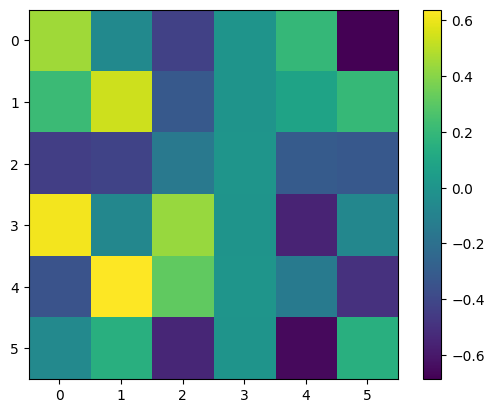

In [38]:
plt.imshow((Aopt))
plt.colorbar()

In [39]:
_lossfn = lambda a: lossfn_jac_jax(a, all_pars, all_fns, all_linear_pars, all_linear_inds, parts=True, X=X, Fs=Fs, n_params=n_params)

_lossfn(Aopt), _lossfn(np.eye(n_params))

((Array(19.652515, dtype=float32),
  Array(0.01351071, dtype=float32),
  Array(193.93889, dtype=float32)),
 (Array(11.926368, dtype=float32),
  Array(0.05573259, dtype=float32),
  Array(224.83926, dtype=float32)))

In [40]:
all_linear_pars, mdl_coords

([array([ 0.198915,  0.740551, -0.254262,  0.231963, -0.131264]),
  array([-5.00000e-06,  9.99998e-01,  1.46357e-01,  2.97831e-01,
         -1.13143e-01,  3.35804e-01, -1.77085e-01]),
  array([-0.04382 ,  1.062336,  0.385171, -0.113036, -0.101597]),
  array([-0.070241,  1.024071,  6.283185,  0.040789, -0.888934]),
  array([ 0.      ,  1.000001,  0.30316 , -0.296884,  0.174063,  0.113381,
          0.132586]),
  array([-4.00000e-06,  9.99999e-01,  1.33432e-01,  2.26473e-01,
          1.68353e-01, -2.66463e-01,  2.62993e-01])],
 ['(0.198915 + (0.740551 * (((sqrt((0.997869 * X4)) + ((-0.254262) * X5)) + (0.231963 * X2)) + ((-0.131264) * X6))))',
  '((-0.000005) + (0.999998 * ((((0.146357 * X2) + (0.297831 * X3)) + ((-0.113143) * X6)) + (0.335804 + ((-0.177085) * X1)))))',
  '((-0.043820) + (1.062336 * ((0.385171 + ((0.001209 * X3) ^ (0.474258 * X4))) + (((-0.113036) * X5) + ((-0.101597) * X6)))))',
  '((-0.070241) + (1.024071 * ((sqrt((5.114736 * X4)) + ((6.283185 * X3) * (0.040789 * X1))

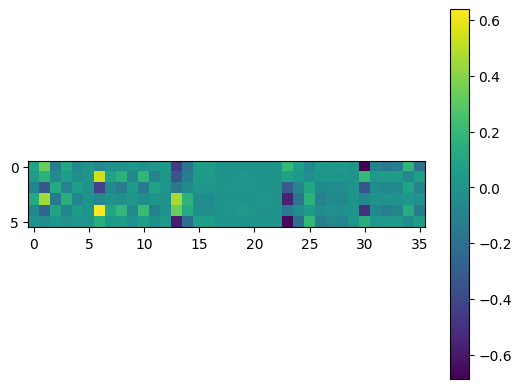

In [41]:
plt.imshow((Aopt @ construct_M(all_linear_pars, n_params=n_params)))
plt.colorbar()

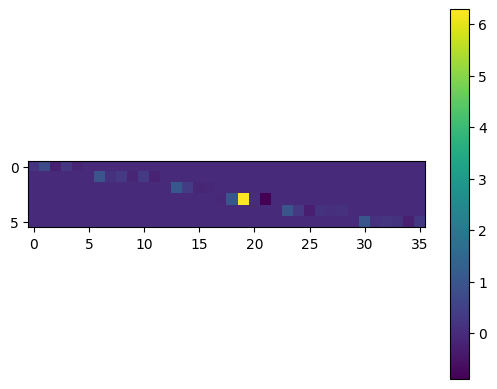

In [42]:
plt.imshow(construct_M(all_linear_pars, n_params=n_params))
plt.colorbar()

In [50]:
get_pruned_expressions(np.eye(n_params), 
                      all_param_dicts,
                       all_pars, all_linear_pars, all_expr, all_linear_labels, remove_floats=False, threshold=1e-20, n_params=n_params
                       )


(['0.172*X2 + 0.74*X4**0.5 - 0.188*X5 - 0.097*X6 + 0.199',
  '-0.177*X1 + 0.146*X2 + 0.298*X3 - 0.113*X6 + 0.336',
  '-0.12*X5 - 0.108*X6 + 1.062*(0.001*X3)**(0.474*X4) + 0.365',
  '0.262*X1*X3 + 2.316*X4**0.5 - 0.91*X4 - 0.07',
  '0.113*X1 + 0.174*X2 - 0.297*X4 + 0.133*X5 + 0.303',
  '0.168*X2 + 0.133*X3 - 0.266*X4 + 0.226*X6 + 0.263'],
 [[0.172, 0.74, 0.5, 0.188, 0.097, 0.199],
  [-0.177, 0.146, 0.298, 0.113, 0.336],
  [-0.12, 0.108, 1.062, 0.001, 0.474, 0.365],
  [0.262, 2.316, 0.5, 0.91, 0.07],
  [0.113, 0.174, 0.297, 0.133, 0.303],
  [0.168, 0.133, 0.266, 0.226, 0.263]])

In [51]:
sr_exprs_vanilla, _ = get_pruned_expressions_final(np.eye(n_params), 
                      all_param_dicts,
                       all_pars, all_linear_pars, 
                       all_expr, all_linear_labels, 
                       remove_floats=False, threshold=0.05, n_params=n_params, X=X_test, Fs=Fs_test
                       )

Looking at component 0
  delta: 0.000000
  zeroed component -> skip!
  delta: 0.754252
  delta: 0.682634
  delta: 0.067816
Looking at component 1
  delta: 0.000000
  zeroed component -> skip!
  delta: 0.032069
  delta: 1.356299
  delta: 0.120147
  delta: 0.032069
  delta: 3.670030
Looking at component 2
  delta: 0.000000
  zeroed component -> skip!
  delta: 0.032069
  delta: 0.884682
  delta: 0.043384
Looking at component 3
  delta: 0.000000
  zeroed component -> skip!
  delta: 5.656615
  delta: 5.656615
  delta: 0.309405
Looking at component 4
  delta: 0.000000
  zeroed component -> skip!
  delta: 0.043384
  delta: 0.142453
  delta: 0.239899
  delta: 0.489822
  delta: 0.214685
Looking at component 5
  delta: 0.000000
  zeroed component -> skip!
  delta: 0.067931
  delta: 4.678417
  delta: 0.330170
  delta: -0.009808
  delta: -0.009808


In [52]:
sr_exprs_vanilla

['0.172*X2 + 0.74*X4**0.5 - 0.188*X5 - 0.097*X6',
 '-0.177*X1 + 0.298*X3 - 0.113*X6',
 '-0.12*X5 + 1.062*(0.001*X3)**(0.474*X4)',
 '0.262*X1*X3 + 2.316*X4**0.5 - 0.91*X4',
 '0.113*X1 + 0.174*X2 - 0.297*X4 + 0.133*X5',
 '0.168*X2 + 0.133*X3 + 0.226*X6']

In [46]:
sr_exprs_vanilla

['0.172*X2 + 0.74*X4**0.5 - 0.188*X5 - 0.097*X6',
 '-0.177*X1 + 0.298*X3 - 0.113*X6',
 '-0.12*X5 + 1.062*(0.001*X3)**(0.474*X4)',
 '0.262*X1*X3 + 2.316*X4**0.5 - 0.91*X4',
 '0.113*X1 + 0.174*X2 - 0.297*X4 + 0.133*X5',
 '0.168*X2 + 0.133*X3 + 0.226*X6']

In [53]:
fit_exprs0, _ = get_pruned_expressions(Aopt, all_param_dicts,
            all_pars, all_linear_pars, all_expr, all_linear_labels, remove_floats=False, threshold=0.1, decimal=3, n_params=n_params)

In [54]:
fit_exprs0

['0.114*X2 + 0.332*X4**0.5 - 0.126*X4 - 0.038*X5 + 0.107*X6 - 0.456*(0.001*X3)**(0.474*X4) + 0.2',
 '0.086*X3 + 0.161*X4**0.5 - 0.336*(0.001*X3)**(0.474*X4) + 0.138',
 '0.033*X2 + 0.052*X3 - 0.325*X4**0.5 - 0.036*X5 - 0.161*(0.001*X3)**(0.474*X4) + 0.059',
 '0.065*X2 + 0.453*X4**0.5 - 0.092*X4 - 0.071*X5 + 0.462*(0.001*X3)**(0.474*X4) + 0.293',
 '-0.072*X1 + 0.121*X3 - 0.258*X4**0.5 - 0.066*X4 + 0.056*X6 + 0.333*(0.001*X3)**(0.474*X4) + 0.243',
 '0.074*X2 - 0.127*X4 - 0.58*(0.001*X3)**(0.474*X4) + 0.251']

In [55]:
fit_exprs, _ = get_pruned_expressions_final(Aopt, all_param_dicts,
            all_pars, all_linear_pars, all_expr, all_linear_labels,
             remove_floats=False, threshold=0.05, n_params=n_params, X=X_test, Fs=Fs_test, decimal=2, update=False, verbose=True)

Looking at component 0
  delta: 0.000000
  delta: 526.271423
  delta: 14426.607422
  delta: 1.764017
  delta: -0.007055
Looking at component 1
  delta: 0.000000
  delta: 278.650879
  delta: 0.496303
  delta: 0.154283
  delta: -0.058235
  delta: -0.058235
  delta: 12.457477
Looking at component 2
  delta: 0.000000
  delta: 3276574.000000
  delta: -0.058235
  delta: 0.453571
  delta: 0.037727
Looking at component 3
  delta: 0.000000
  delta: 0.035805
  delta: 0.035805
  delta: 0.035805
  delta: 0.035805
Looking at component 4
  delta: 0.000000
  delta: 1.100600
  delta: 0.035805
  delta: 0.029592
  delta: 0.099106
  delta: 1.309636
  delta: 0.067360
Looking at component 5
  delta: 0.000000
  delta: -0.264550
  delta: -0.264550
  delta: -0.264550
  delta: -0.264550
  delta: -0.264550
  delta: -0.264550


In [56]:
fit_exprs

['-0.46*0**X4 + 0.04*X2 + 0.33*X4**0.5 - 0.06*X5',
 '-0.34*0**X4 - 0.05*X1 + 0.05*X2 + 0.09*X3 + 0.16*X4**0.5 - 0.02*X5',
 '-0.16*0**X4 - 0.02*X1 + 0.08*X2 + 0.05*X3 - 0.33*X4**0.5 - 0.03*X5',
 '0.46*0**X4 + 0.03*X1 + 0.12*X2 + 0.45*X4**0.5 - 0.05*X5',
 '0.33*0**X4 - 0.07*X1 + 0.08*X2 + 0.12*X3 - 0.26*X4**0.5 - 0.03*X5',
 '-0.58*0**X4 + 0.04*X1 + 0.08*X2 + 0.01*X3 - 0.05*X4**0.5 + 0.02*X5']

In [57]:

check_flats = lambda c: check_flattening(c, X=X, Fs=Fs)

In [58]:
n_d = 1
mdl_flats, mdl_J = check_flats(mdl_coords)
frob_flats, frob_J = check_flats(frob_coords)

In [59]:
from copy import deepcopy
fit_exprs2 = deepcopy(fit_exprs)

# substitute in mdl coordinates for zero components
# fit_exprs2[1] ="0.0" 
# fit_exprs2[0] = "0.0"

fit_exprs2, mdl_coords

(['-0.46*0**X4 + 0.04*X2 + 0.33*X4**0.5 - 0.06*X5',
  '-0.34*0**X4 - 0.05*X1 + 0.05*X2 + 0.09*X3 + 0.16*X4**0.5 - 0.02*X5',
  '-0.16*0**X4 - 0.02*X1 + 0.08*X2 + 0.05*X3 - 0.33*X4**0.5 - 0.03*X5',
  '0.46*0**X4 + 0.03*X1 + 0.12*X2 + 0.45*X4**0.5 - 0.05*X5',
  '0.33*0**X4 - 0.07*X1 + 0.08*X2 + 0.12*X3 - 0.26*X4**0.5 - 0.03*X5',
  '-0.58*0**X4 + 0.04*X1 + 0.08*X2 + 0.01*X3 - 0.05*X4**0.5 + 0.02*X5'],
 ['(0.198915 + (0.740551 * (((sqrt((0.997869 * X4)) + ((-0.254262) * X5)) + (0.231963 * X2)) + ((-0.131264) * X6))))',
  '((-0.000005) + (0.999998 * ((((0.146357 * X2) + (0.297831 * X3)) + ((-0.113143) * X6)) + (0.335804 + ((-0.177085) * X1)))))',
  '((-0.043820) + (1.062336 * ((0.385171 + ((0.001209 * X3) ^ (0.474258 * X4))) + (((-0.113036) * X5) + ((-0.101597) * X6)))))',
  '((-0.070241) + (1.024071 * ((sqrt((5.114736 * X4)) + ((6.283185 * X3) * (0.040789 * X1))) + ((-0.888934) * X4))))',
  '(0.000000 + (1.000001 * (((0.303160 + ((-0.296884) * X4)) + (0.174063 * X2)) + ((0.113381 * X1) + (0

In [60]:
n_params

In [61]:
n_d = 1
fit_expr_flats0, _ = check_flats(fit_exprs0)
sr_expr_flats, _ = check_flats(sr_exprs_vanilla)

fit_expr_flats, _ = check_flattening(fit_exprs, X=X, Fs=Fs)


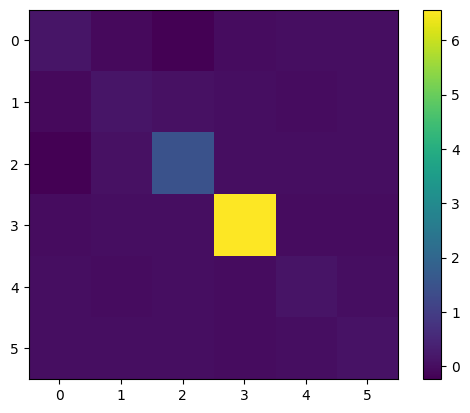

In [62]:
plt.imshow(Fs.mean(0))
plt.colorbar()

In [63]:
sr_exprs_vanilla

['0.172*X2 + 0.74*X4**0.5 - 0.188*X5 - 0.097*X6',
 '-0.177*X1 + 0.298*X3 - 0.113*X6',
 '-0.12*X5 + 1.062*(0.001*X3)**(0.474*X4)',
 '0.262*X1*X3 + 2.316*X4**0.5 - 0.91*X4',
 '0.113*X1 + 0.174*X2 - 0.297*X4 + 0.133*X5',
 '0.168*X2 + 0.133*X3 + 0.226*X6']

In [65]:
from sr_utils import norm

In [66]:
jax.vmap(norm)(sr_expr_flats - jnp.eye(n_params)).mean()

Array(10.782819, dtype=float32)

In [67]:
jax.vmap(norm)(fit_expr_flats0 - jnp.eye(n_params)).mean()

Array(398750., dtype=float32)

In [68]:
jax.vmap(norm)(fit_expr_flats - jnp.eye(n_params)).mean()

Array(8412.452, dtype=float32)

In [69]:
jax.vmap(norm)(mdl_flats - jnp.eye(n_params)).mean()

Array(10.49717, dtype=float32)

In [70]:
jax.vmap(norm)(sr_expr_flats - jnp.eye(n_params)).mean()

Array(10.782819, dtype=float32)

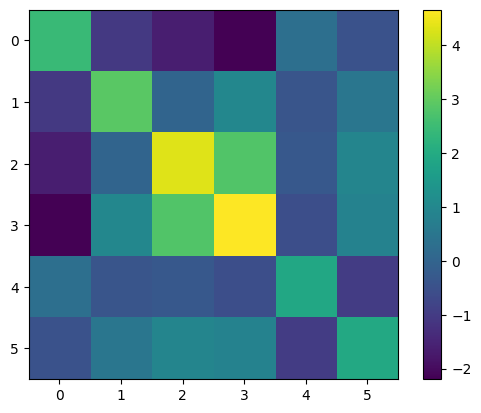

In [71]:
plt.imshow(mdl_flats.mean(0))
plt.colorbar()

In [72]:
mdl_flats = jax.vmap(flatten_with_numerical_jacobian)(mdl_J, Fs)
frob_flats = jax.vmap(flatten_with_numerical_jacobian)(frob_J, Fs)

In [73]:
mdl_flats.mean(0), frob_flats.mean(0)

(Array([[ 2.4563215 , -1.0552682 , -1.6116586 , -2.198395  ,  0.31886175,
         -0.45933005],
        [-1.0552682 ,  2.8924005 ,  0.0187435 ,  0.9797838 , -0.3962306 ,
          0.4948252 ],
        [-1.6116586 ,  0.01874351,  4.3202133 ,  2.7871516 , -0.3198155 ,
          0.9111278 ],
        [-2.198395  ,  0.9797837 ,  2.7871516 ,  4.6589937 , -0.5573241 ,
          0.84254825],
        [ 0.31886175, -0.3962306 , -0.3198155 , -0.5573241 ,  1.9079554 ,
         -0.97712374],
        [-0.45933005,  0.4948252 ,  0.9111278 ,  0.84254825, -0.97712374,
          1.9275173 ]], dtype=float32),
 Array([[ 2.8447805e+01,  2.0813373e-01, -8.6300301e+01, -3.1287025e+01,
         -3.8451397e+01,  1.2385985e+01],
        [ 2.0813373e-01,  9.5604038e+00, -5.0367942e+00, -6.4598179e+00,
         -8.5565939e+00,  1.4313170e-01],
        [-8.6300301e+01, -5.0367942e+00,  2.7821011e+02,  1.0166744e+02,
          1.2678721e+02, -3.9813797e+01],
        [-3.1287025e+01, -6.4598179e+00,  1.0166744e+02,

In [74]:
#@title fisher code
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

def plot_fisher_ellipse(fisher_matrix, mean=None, ax=None, color='blue', 
                        alpha=1.0, linestyle='-',
                       label=""):
    """
    Plots a Fisher information matrix ellipse.

    Parameters:
        fisher_matrix (numpy.ndarray): Fisher information matrix.
        mean (numpy.ndarray, optional): Mean vector. Defaults to None, in which case the ellipse will be centered at (0, 0).
        ax (matplotlib.axes.Axes, optional): Axes to plot on. If not provided, a new figure will be created.
        color (str, optional): Color of the ellipse. Defaults to 'blue'.
        alpha (float, optional): Transparency of the ellipse. Defaults to 0.5.
        linestyle (str, optional): Linestyle of the ellipse. Defaults to '-'.

    Returns:
        matplotlib.axes.Axes: Axes object with the ellipse plotted.
    """
    if ax is None:
        _, ax = plt.subplots()

    # Invert the Fisher information matrix to get the covariance matrix
    covariance_matrix = np.linalg.inv(fisher_matrix)

    # Calculate eigenvalues and eigenvectors of the covariance matrix
    eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)
    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    # Calculate ellipse angle
    angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))

    # If mean is provided, set the center of the ellipse accordingly
    if mean is not None:
        center = mean
    else:
        center = np.zeros_like(covariance_matrix.shape[0])

    # Create ellipse for 1-sigma contour
    ellipse = Ellipse(xy=center,
                      width=2 * np.sqrt(eigenvalues[0]),
                      height=2 * np.sqrt(eigenvalues[1]),
                      angle=angle,
                      edgecolor=color,
                      linestyle=linestyle,
                      facecolor='none',
                      alpha=alpha,
                      label=label)

    # Create ellipse for 2-sigma contour
    ellipse2 = Ellipse(xy=center,
                       width=2 * 2 * np.sqrt(eigenvalues[0]),
                       height=2 * 2 * np.sqrt(eigenvalues[1]),
                       angle=angle,
                       edgecolor=color,
                       linestyle=linestyle,
                       facecolor='none',
                       alpha=alpha)

    ax.add_patch(ellipse)
    ax.add_patch(ellipse2)
    #ax.set_aspect('equal', 'box')
    ax.autoscale()
    return ax

In [75]:
#nn_flats = jax.vmap(jax.vmap(flatten_with_numerical_jacobian))(dys, ensemble_Fs).mean(0)

nn_flats = jax.vmap(flatten_with_numerical_jacobian)(dy, Fs)

In [76]:
Fs, dy

(array([[[ 1.79591939e-01, -7.33189583e-02, -1.24796897e-01,
          -7.79308053e-03, -5.81283635e-03,  1.16888471e-02],
         [-7.33189583e-02,  1.45286441e-01,  6.55122995e-02,
          -1.37311826e-02, -1.28430761e-02,  7.17298267e-03],
         [-1.24796897e-01,  6.55122995e-02,  1.49071470e-01,
           2.48202519e-03,  3.14184627e-03, -7.76583143e-03],
         [-7.79308053e-03, -1.37311826e-02,  2.48202519e-03,
           3.20214450e-01,  9.45476722e-03, -2.39792410e-02],
         [-5.81283635e-03, -1.28430761e-02,  3.14184627e-03,
           9.45476722e-03,  1.07455745e-01,  4.82877204e-03],
         [ 1.16888471e-02,  7.17298267e-03, -7.76583143e-03,
          -2.39792410e-02,  4.82877204e-03,  1.24740891e-01]],
 
        [[ 1.81986883e-01, -7.73589462e-02, -1.45884797e-01,
          -4.36851718e-02, -1.15073016e-02,  8.85508768e-03],
         [-7.73589462e-02,  1.38309687e-01,  7.04474673e-02,
           2.69424673e-02, -3.46858567e-03, -4.63654753e-03],
         [-1.

In [77]:
nn_flats = jax.vmap(flatten_with_numerical_jacobian)(dy, Fs)
nn_flats.mean(0)

Array([[ 1.0556262e+00, -1.4660488e-02, -3.3149019e-02,  1.3279779e-03,
        -6.1197284e-06, -1.0251725e-02],
       [-1.4660488e-02,  1.1786869e+00,  1.4679173e-03, -3.3413339e-02,
        -5.9600431e-02,  6.9838136e-02],
       [-3.3149015e-02,  1.4679193e-03,  1.1639644e+00, -9.0068229e-02,
        -3.8245160e-02, -3.5979010e-02],
       [ 1.3279784e-03, -3.3413339e-02, -9.0068229e-02,  1.1687694e+00,
         5.7759594e-02,  3.2047663e-02],
       [-6.1206820e-06, -5.9600435e-02, -3.8245160e-02,  5.7759594e-02,
         1.0779908e+00, -2.8643925e-03],
       [-1.0251724e-02,  6.9838136e-02, -3.5979010e-02,  3.2047663e-02,
        -2.8643922e-03,  1.0846261e+00]], dtype=float32)

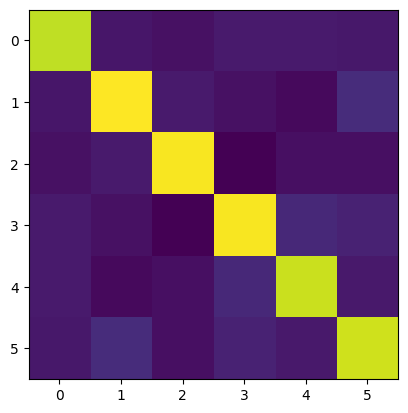

In [78]:
plt.imshow(nn_flats.mean(0))

In [79]:
from preprocessing_utils import get_eigenvalues as get_evalues
evalues_nn = jax.vmap(get_evalues)(nn_flats)
evalues_mdl = jax.vmap(get_evalues)(mdl_flats)
evalues_frob = jax.vmap(get_evalues)(frob_flats)

evalues_fitexpr = jax.vmap(get_evalues)(sr_expr_flats)

In [80]:
evalues_fitexpr

Array([[ 0.6571935 ,  0.7232051 ,  1.0049204 ,  2.1425016 ,  3.3519228 ,
         9.638329  ],
       [ 0.63709116,  0.80284953,  1.3216833 ,  1.9427859 ,  2.4971802 ,
         8.73869   ],
       [ 0.51114404,  0.6022346 ,  0.7814536 ,  2.376276  ,  3.0100012 ,
         8.300582  ],
       ...,
       [ 0.65956026,  0.8116022 ,  2.09662   ,  3.7622583 ,  6.1766744 ,
        12.629536  ],
       [ 0.43177804,  0.8031032 ,  0.99618024,  1.8135083 ,  2.6262283 ,
         6.8099165 ],
       [ 0.45314252,  0.84253377,  0.97342503,  1.2648287 ,  2.1376836 ,
         4.695568  ]], dtype=float32)

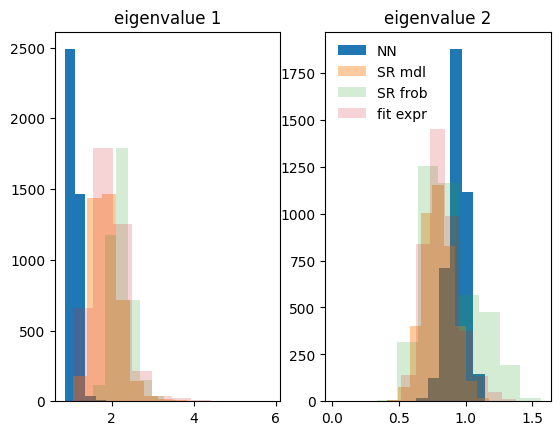

In [81]:
plt.subplot(121)
plt.title("eigenvalue 1")

plt.hist(evalues_nn[:, 3], label="NN")
plt.hist(evalues_mdl[:, 3], alpha=0.4, label="SR mdl")
plt.hist(evalues_frob[:, 3], alpha=0.2, label="SR frob")
plt.hist(evalues_fitexpr[:, 3], alpha=0.2, label="fit expr")


plt.subplot(122)
plt.title("eigenvalue 2")
plt.hist(evalues_nn[:, 1], label="NN")
plt.hist(evalues_mdl[:, 1], alpha=0.4, label="SR mdl")
plt.hist(evalues_frob[:, 1], alpha=0.2, label="SR frob")
plt.hist(evalues_fitexpr[:, 1], alpha=0.2, label="fit expr")


plt.legend(framealpha=0.0)

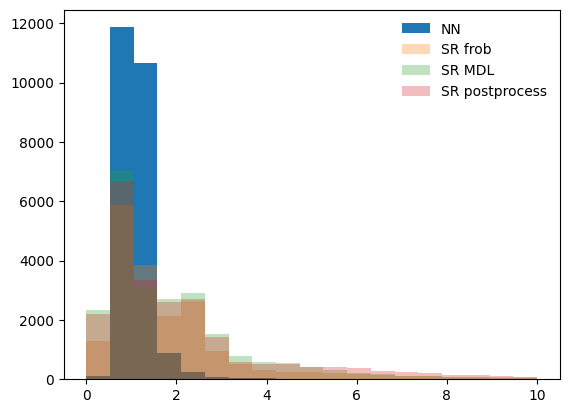

In [82]:
bins = np.linspace(0, 10, 20)
plt.hist(np.array(evalues_nn).flatten(), bins=bins, label='NN')
plt.hist(np.array(evalues_frob).flatten(), bins=bins, alpha=0.3, label='SR frob')
plt.hist(np.array(evalues_mdl).flatten(), bins=bins, alpha=0.3, label='SR MDL')
plt.hist(np.array(evalues_fitexpr).flatten(), bins=bins, alpha=0.3, label='SR postprocess')
plt.legend(framealpha=0.0)

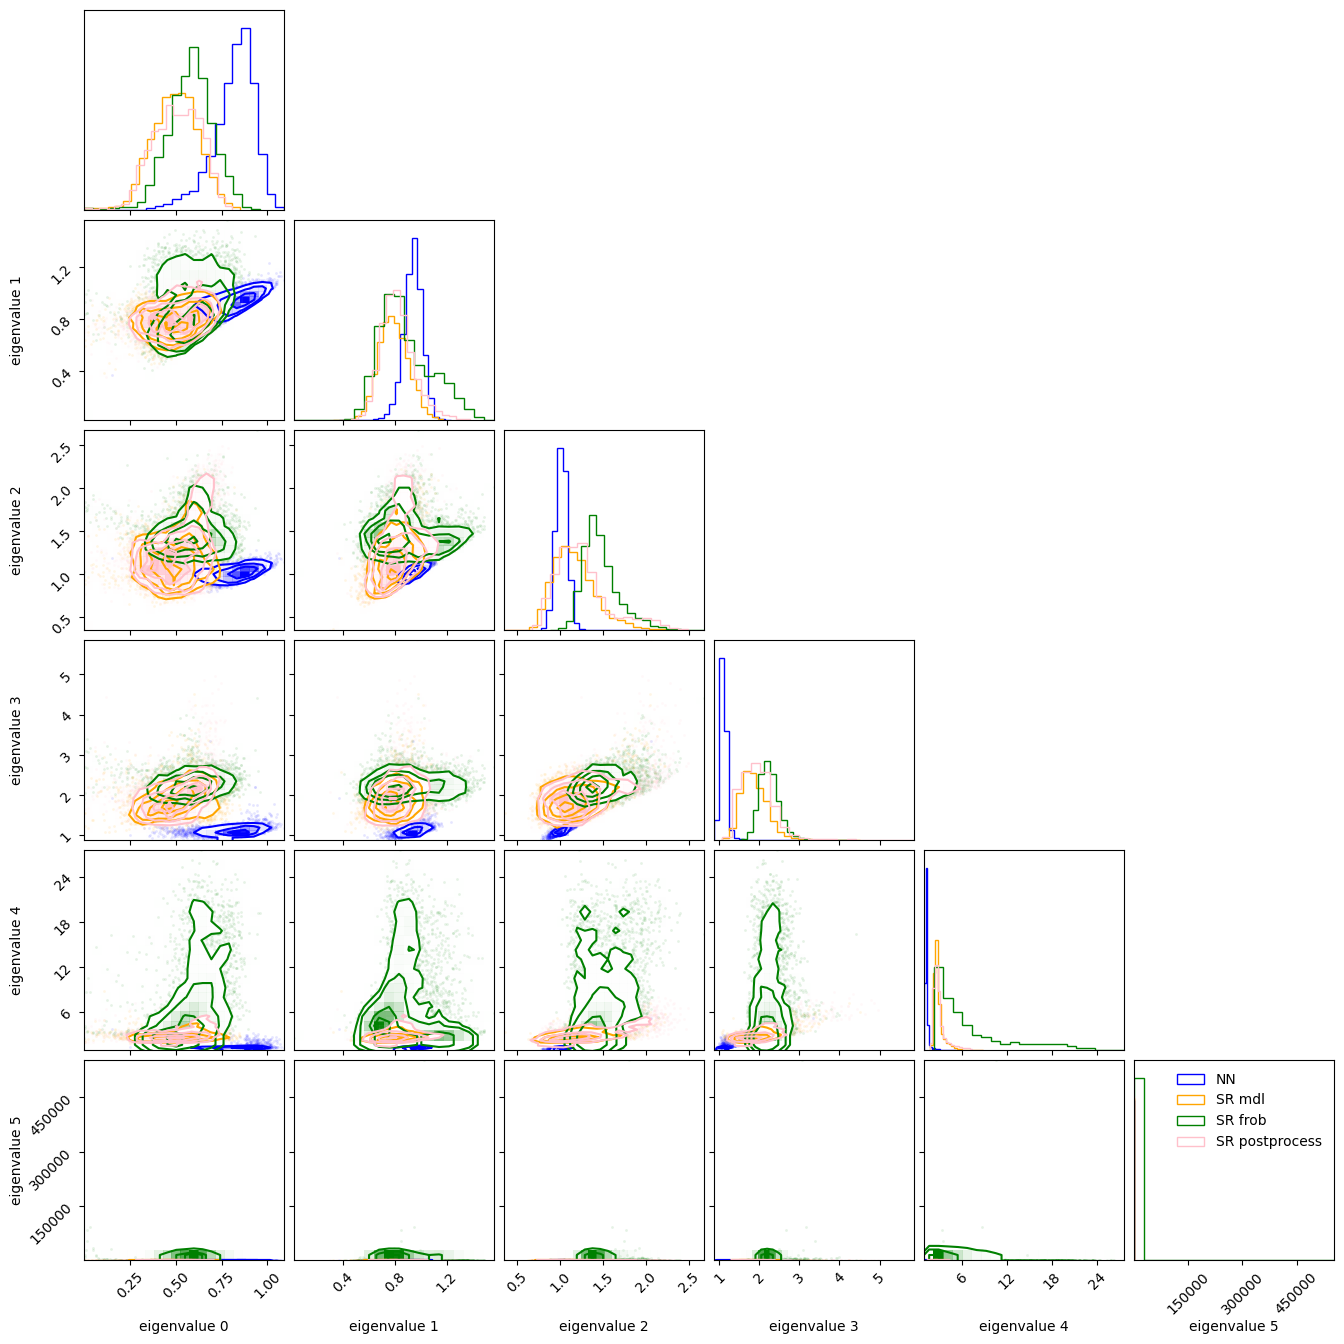

In [84]:
import corner

cols = ['eigenvalue %d'%(i) for i in range(n_params)]

figure = corner.corner(np.array(evalues_nn), color="blue", labels=cols, hist_kwargs=dict(label="NN"))
figure = corner.corner(np.array(evalues_mdl), color="orange", fig=figure, labels=cols, alpha=0.2, hist_kwargs=dict(label="SR mdl"))
figure = corner.corner(np.array(evalues_frob), color="green", fig=figure, labels=cols, alpha=0.2, hist_kwargs=dict(label="SR frob"))
figure = corner.corner(np.array(evalues_fitexpr), color="pink", fig=figure, labels=cols, alpha=0.2, hist_kwargs=dict(label="SR postprocess"))


plt.legend(framealpha=0.0)


In [85]:
nn_flats

Array([[[ 1.00980687e+00,  1.75279081e-02,  1.63147628e-01,
          6.49733990e-02,  4.43253219e-02,  9.18522179e-02],
        [ 1.75278634e-02,  9.21499968e-01, -5.11294156e-02,
          2.34855413e-02,  3.46540734e-02, -2.82507986e-02],
        [ 1.63147673e-01, -5.11293113e-02,  1.08728909e+00,
         -1.27761096e-01, -3.14921737e-02, -1.50711015e-01],
        [ 6.49734139e-02,  2.34855562e-02, -1.27761096e-01,
          1.08971524e+00, -6.56387806e-02, -3.26598287e-02],
        [ 4.43252623e-02,  3.46540958e-02, -3.14921141e-02,
         -6.56386912e-02,  9.25734043e-01, -3.98407876e-03],
        [ 9.18521881e-02, -2.82508135e-02, -1.50711104e-01,
         -3.26598585e-02, -3.98413837e-03,  1.19370914e+00]],

       [[ 1.08300769e+00, -1.41785145e-02, -1.74105763e-02,
          6.24239445e-04, -3.42247188e-02,  3.07111442e-03],
        [-1.41785741e-02,  1.04332745e+00,  4.41142544e-02,
         -5.26413620e-02,  2.31264979e-02,  2.16525048e-02],
        [-1.74105912e-02,  4.4

In [95]:
nn_flats[:, [0,1],].shape

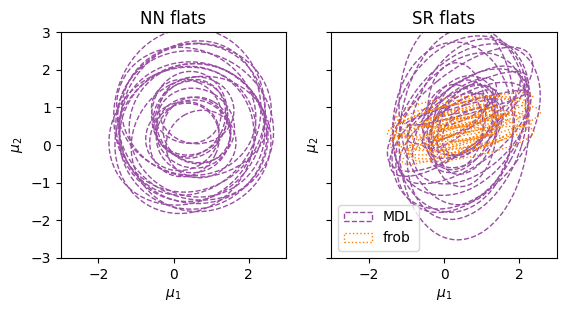

In [101]:
# plot a smattering of fishers

randidx = np.random.choice(500, size=(12), replace=False)


_, axs = plt.subplots(1, 2, sharey=True) 


comps_to_plot = [0,3]

ax = axs[0]

for i,r in enumerate(randidx):
    if i == 0:
        ax = plot_fisher_ellipse(nn_flats[:, comps_to_plot, :][:, :, comps_to_plot][r],ax=ax, mean=X_test[r], color=cm(3), linestyle='--')

    else: 
        if i == len(randidx) - 1:
            labels = ["MDL", "score"]
        else:
            labels = [None, None]
            
        plot_fisher_ellipse(nn_flats[:, comps_to_plot, :][:, :, comps_to_plot][r], mean=X_test[:, comps_to_plot][r], ax=ax, label=labels[0], linestyle='--', color=cm(3))
        #plot_fisher_ellipse(score_flats[r], mean=X[r], ax=ax, label=labels[1], linestyle=':', color=cm(2))



ax.set_ylabel(r"$\mu_2$")
ax.set_xlabel(r"$\mu_1$")
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_title("NN flats")
ax.set_box_aspect(1)
ax = axs[1]

mdl_evalues = []

for i,r in enumerate(randidx):
    if i == 0:
        ax = plot_fisher_ellipse(mdl_flats[:, comps_to_plot, :][:, :, comps_to_plot][r],ax=ax, mean=X_test[:, comps_to_plot][r], color=cm(3), linestyle='--')

    else: 
        if i == len(randidx) - 1:
            labels = ["MDL", "frob"]
        else:
            labels = [None, None]
        
        plot_fisher_ellipse(mdl_flats[:, comps_to_plot, :][:, :, comps_to_plot][r], mean=X_test[r], ax=ax, label=labels[0], linestyle='--', color=cm(3))


for i,r in enumerate(randidx):
    if i == 0:
        ax = plot_fisher_ellipse(frob_flats[:, comps_to_plot, :][:, :, comps_to_plot][r],ax=ax, mean=X_test[:, comps_to_plot][r], color=cm(3), linestyle='--')

    else: 
        if i == len(randidx) - 1:
            labels = ["MDL", "frob"]
        else:
            labels = [None, None]
        
        plot_fisher_ellipse(frob_flats[:, comps_to_plot, :][:, :, comps_to_plot][r], mean=X_test[:, comps_to_plot][r], ax=ax, label=labels[1], linestyle=':', color=cm(4))



ax.set_ylabel(r"$\mu_2$")
ax.set_xlabel(r"$\mu_1$")
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_title("SR flats")

ax.set_box_aspect(1)


plt.legend()

#plt.tight_layout()

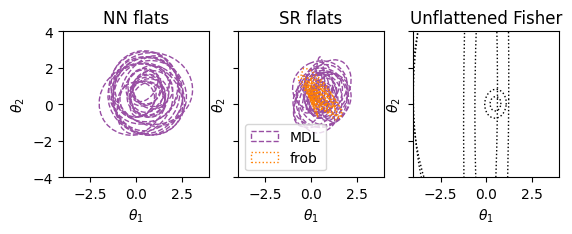

In [115]:
# plot a smattering of fishers

randidx = np.random.choice(500, size=(12), replace=False)


comps_to_plot = [2,4]


_, axs = plt.subplots(1, 3, sharey=True)


ax = axs[0]

for i,r in enumerate(randidx):
    if i == 0:
        ax = plot_fisher_ellipse(nn_flats[:, comps_to_plot, :][:, :, comps_to_plot][r],ax=ax, mean=X[:, comps_to_plot][r], color=cm(3), linestyle='--')

    else: 
        if i == len(randidx) - 1:
            labels = ["MDL", "score"]
        else:
            labels = [None, None]
            
        plot_fisher_ellipse(nn_flats[:, comps_to_plot, :][:, :, comps_to_plot][r], mean=X_test[:, comps_to_plot][r], ax=ax, label=labels[0], linestyle='--', color=cm(3))
        #plot_fisher_ellipse(score_flats[r], mean=X[r], ax=ax, label=labels[1], linestyle=':', color=cm(2))



ax.set_ylabel(r"$\theta_2$")
ax.set_xlabel(r"$\theta_1$")
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.set_title("NN flats")
ax.set_box_aspect(1)
ax = axs[1]

mdl_evalues = []

for i,r in enumerate(randidx):
    if i == 0:
        ax = plot_fisher_ellipse(mdl_flats[:, comps_to_plot, :][:, :, comps_to_plot][r],ax=ax, mean=X_test[:, comps_to_plot][r], color=cm(3), linestyle='--')

    else: 
        if i == len(randidx) - 1:
            labels = ["MDL", "frob"]
        else:
            labels = [None, None]
        
        plot_fisher_ellipse(mdl_flats[:, comps_to_plot, :][:, :, comps_to_plot][r], mean=X_test[:, comps_to_plot][r], ax=ax, label=labels[0], linestyle='--', color=cm(3))


for i,r in enumerate(randidx):
    if i == 0:
        ax = plot_fisher_ellipse(frob_flats[:, comps_to_plot, :][:, :, comps_to_plot][r],ax=ax, mean=X_test[:, comps_to_plot][r], color=cm(3), linestyle='--')

    else: 
        if i == len(randidx) - 1:
            labels = ["MDL", "frob"]
        else:
            labels = [None, None]
        
        plot_fisher_ellipse(frob_flats[:, comps_to_plot, :][:, :, comps_to_plot][r], mean=X[:, comps_to_plot][r], ax=ax, label=labels[1], linestyle=':', color=cm(4))

ax.legend()

ax.set_ylabel(r"$\theta_2$")
ax.set_xlabel(r"$\theta_1$")
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.set_title("SR flats")


ax.set_box_aspect(1)




ax = axs[2]

for i,r in enumerate(randidx):
    if i == 0:
        ax = plot_fisher_ellipse(Fs_test[:, comps_to_plot, :][:, :, comps_to_plot][r]*50,ax=ax, mean=X_test[:, comps_to_plot][r], color='k', linestyle=':')

    else: 
        if i == len(randidx) - 1:
            labels = ["MDL", "frob"]
        else:
            labels = [None, None]
            
        plot_fisher_ellipse(Fs_test[:, comps_to_plot, :][:, :, comps_to_plot][r] / 10., mean=X_test[:, comps_to_plot][r], ax=ax, label=labels[1], linestyle=':', color='k')
        #plot_fisher_ellipse(score_flats[r], mean=X[r], ax=ax, label=labels[1], linestyle=':', color=cm(2))




ax.set_ylabel(r"$\theta_2$")
ax.set_xlabel(r"$\theta_1$")
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.set_title("Unflattened Fisher")
ax.set_box_aspect(1)



#plt.tight_layout()

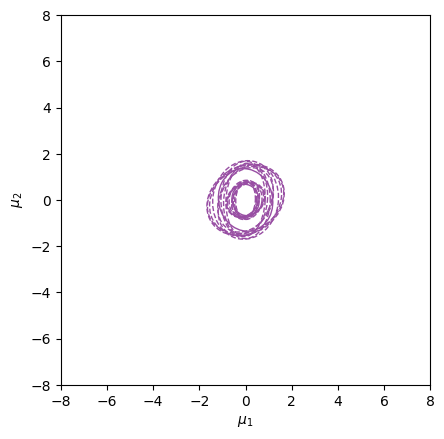

In [116]:
# plot a smattering of fishers

randidx = np.random.choice(1000, size=(10), replace=False)


for i,r in enumerate(randidx):
    if i == 0:
        ax = plot_fisher_ellipse(mdl_flats[:, comps_to_plot, :][:, :, comps_to_plot][r], mean=np.array([0, 0]), color=cm(3))

    else: 
        if i == len(randidx) - 1:
            labels = ["MDL", "score"]
        else:
            labels = [None, None]
            
        plot_fisher_ellipse(mdl_flats[:, comps_to_plot, :][:, :, comps_to_plot][r], mean=np.array([0, 0]), ax=ax, label=labels[0], linestyle='--', color=cm(3))
        #plot_fisher_ellipse(score_flats[r], mean=np.array([0, 0]), ax=ax, label=labels[1], linestyle=':', color=cm(2))

ax.set_ylabel(r"$\mu_2$")
ax.set_xlabel(r"$\mu_1$")
ax.set_xlim(-8,8)
ax.set_ylim(-8, 8)
ax.set_box_aspect(1)
#plt.legend()